In [79]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.sans-serif']=['SimHei']

In [80]:
df = pd.read_csv("F:\\album\\goldstock\\gold_stock.csv")
df = df.drop([0,1])
df = df.reset_index(drop=True)
df = df.rename(columns={"Price":"date"})
print(df.info())
print(df.head())
print(f"NULL number:\n{df.isnull().sum()}")
df.to_csv("F:\\album\\goldstock\\gold_stock_clean.csv",index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    2968 non-null   object
 1   Close   2968 non-null   object
 2   High    2968 non-null   object
 3   Low     2968 non-null   object
 4   Open    2968 non-null   object
 5   Volume  2968 non-null   object
dtypes: object(6)
memory usage: 139.3+ KB
None
         date              Close                High                 Low  \
0  2014-03-17  4.711997032165527    4.85016815549002   4.425025639793251   
1  2014-03-18  5.048568248748779   5.278853682840762   4.694282757608514   
2  2014-03-19  4.959996223449707  5.1017102661133835    4.90685354191906   
3  2014-03-20  4.959996223449707   4.959996223449707   4.889493292947593   
4  2014-03-21   4.69074010848999    4.92456849288367  4.6057116665055595   

                Open  Volume  
0  4.425025639793251   68200  
1  4.711997099740122  135600  
2  5.0131

           Close      High       Low      Open    Volume
Close   1.000000  0.999584  0.999589  0.999112  0.626306
High    0.999584  1.000000  0.999430  0.999572  0.633196
Low     0.999589  0.999430  1.000000  0.999503  0.619312
Open    0.999112  0.999572  0.999503  1.000000  0.625456
Volume  0.626306  0.633196  0.619312  0.625456  1.000000


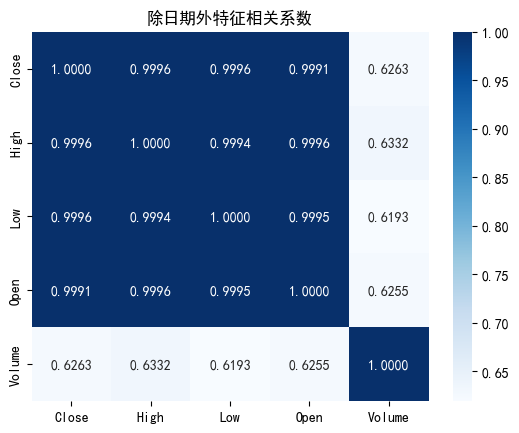

In [81]:
df_no_date = df.drop(columns="date") 
print(df_no_date.corr())
sns.heatmap(df_no_date.corr(),annot=True,cmap="Blues",fmt=".4f")
plt.title("除日期外特征相关系数")
plt.show()

In [82]:
df = pd.read_csv("F:\\album\\goldstock\\gold_stock_clean.csv",index_col="date",parse_dates=['date'])
print(df.head())
target = "Close"
series = df[target].copy()

print(f"数据时间范围: {series.index.min()} 至 {series.index.max()}")
print(f"总样本数: {len(series)}")

train_size = int(len(series)*0.9)
train,test = series[:train_size],series[train_size:]
print(f"训练集大小：{len(train)},测试集大小：{len(test)}")

               Close      High       Low      Open  Volume
date                                                      
2014-03-17  4.711997  4.850168  4.425026  4.425026   68200
2014-03-18  5.048568  5.278854  4.694283  4.711997  135600
2014-03-19  4.959996  5.101710  4.906854  5.013139   25600
2014-03-20  4.959996  4.959996  4.889493  4.959996    8200
2014-03-21  4.690740  4.924568  4.605712  4.924568   10600
数据时间范围: 2014-03-17 00:00:00 至 2025-12-31 00:00:00
总样本数: 2968
训练集大小：2671,测试集大小：297


说明，本次采用两种方式XGboost与SARIMAX

In [83]:
#给XGBOOST准备的
def create_features(data, target_col, lags = [1,2,3,4,5,6,7,14,21,28],windows = [7,14,30]):
    """
    为时间序列构造滞后和滚动统计特征
    参数说明：
        data：dataFrame 包含目标列
        target_col: 目标列名字
        lags：滞后列表
        windows：窗口滚动列表
    返回：
        dataframe目标列
    """
    df_feat = data.copy()
    #滞后特征
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat[target_col].shift(lag)

    #滚动统计
    for win in windows:
        df_feat[f'rolling_mean_{win}'] = df_feat[target_col].rolling(win).mean()
        df_feat[f'rolling_std_{win}'] = df_feat[target_col].rolling(win).std()
        df_feat[f'rolling_min_{win}'] = df_feat[target_col].rolling(win).min()
        df_feat[f'rolling_max_{win}'] = df_feat[target_col].rolling(win).max()
    #时间特征
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    df_feat['quarter'] = df_feat.index.quarter
    df_feat['year'] = df_feat.index.year

    df_feat.dropna(inplace=True)
    return df_feat

#评估函数
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{model_name} 评估结果:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    return rmse, mae, mape

In [84]:
full_data = pd.concat([train,test],axis = 0)
full_feat = create_features(full_data.to_frame(),target)

In [85]:
full_feat.head()

,Close,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_14,lag_21,...,rolling_min_14,rolling_max_14,rolling_mean_30,rolling_std_30,rolling_min_30,rolling_max_30,dayofweek,month,quarter,year
date,,,,,,,,,,,,,,,,,,,,,
2014-04-28,4.180569,4.166396,3.989255,4.162855,4.169942,4.145141,4.251425,4.215997,4.428568,4.651769,...,3.989255,4.304569,4.441441,0.279972,3.989255,5.048568,0,4,2,2014
2014-04-29,4.194741,4.180569,4.166396,3.989255,4.162855,4.169942,4.145141,4.251425,4.304569,4.605712,...,3.989255,4.254970,4.424199,0.278660,3.989255,5.048568,1,4,2,2014
2014-04-30,4.102627,4.194741,4.180569,4.166396,3.989255,4.162855,4.169942,4.145141,4.251425,4.648226,...,3.989255,4.254970,4.392668,0.258352,3.989255,4.959996,2,4,2,2014
2014-05-01,4.130969,4.102627,4.194741,4.180569,4.166396,3.989255,4.162855,4.169942,4.254970,4.634054,...,3.989255,4.251425,4.365034,0.239205,3.989255,4.959996,3,5,2,2014
2014-05-02,4.152226,4.130969,4.102627,4.194741,4.180569,4.166396,3.989255,4.162855,4.240798,4.609254,...,3.989255,4.251425,4.338108,0.214066,3.989255,4.761595,4,5,2,2014


In [86]:
train_feat = full_feat.loc[train.index[0]:train.index[-1]]
test_feat = full_feat.loc[test.index[0]:test.index[-1]]
feature_cols = [col for col in train_feat.columns if col != target]
X_train = train_feat[feature_cols]
y_train = train_feat[target]
X_test = test_feat[feature_cols]
y_test = test_feat[target]

print(f"训练特征形状{X_train.shape},测试特征{X_test.shape}")

训练特征形状(2642, 26),测试特征(297, 26)


In [87]:
model_sarimax = SARIMAX(train,
                        order=(1,1,1),
                        seasonal_order=(1,0,1,14),
                        enforce_invertibility=False,
                        enforce_stationarity=False
                        )
sarimax_fit = model_sarimax.fit(disp=False)
#print(sarimax_fit.summary())
sarimax_pred = sarimax_fit.forecast(steps=len(test))
sarimax_pred.index = test.index
_ ,_ ,_ = evaluate(test,sarimax_pred,"SARIMAX")


d:\python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SARIMAX 评估结果:
  RMSE: 12.5336
  MAE:  11.9400
  MAPE: 49.57%


d:\python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [88]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

split_idx = int(len(X_train_scaled)*0.9)
X_train_, X_val_ = X_train_scaled[:split_idx], X_train_scaled[split_idx:]
y_train_, y_val_ = y_train[:split_idx], y_train[split_idx:]

In [89]:
model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=67,
    early_stopping_rounds=75,
    eval_metric='mae'
)

model_xgb.fit(
    X_train_, y_train_,
    eval_set=[(X_train_, y_train_), (X_val_, y_val_)],
    verbose=False
)

xgb_pred = model_xgb.predict(X_test_scaled)
xgb_pred = pd.Series(xgb_pred, index=test.index)

_ ,_ ,_ =evaluate(test, xgb_pred, "XGBoost")

XGBoost 评估结果:
  RMSE: 0.8577
  MAE:  0.6498
  MAPE: 2.57%


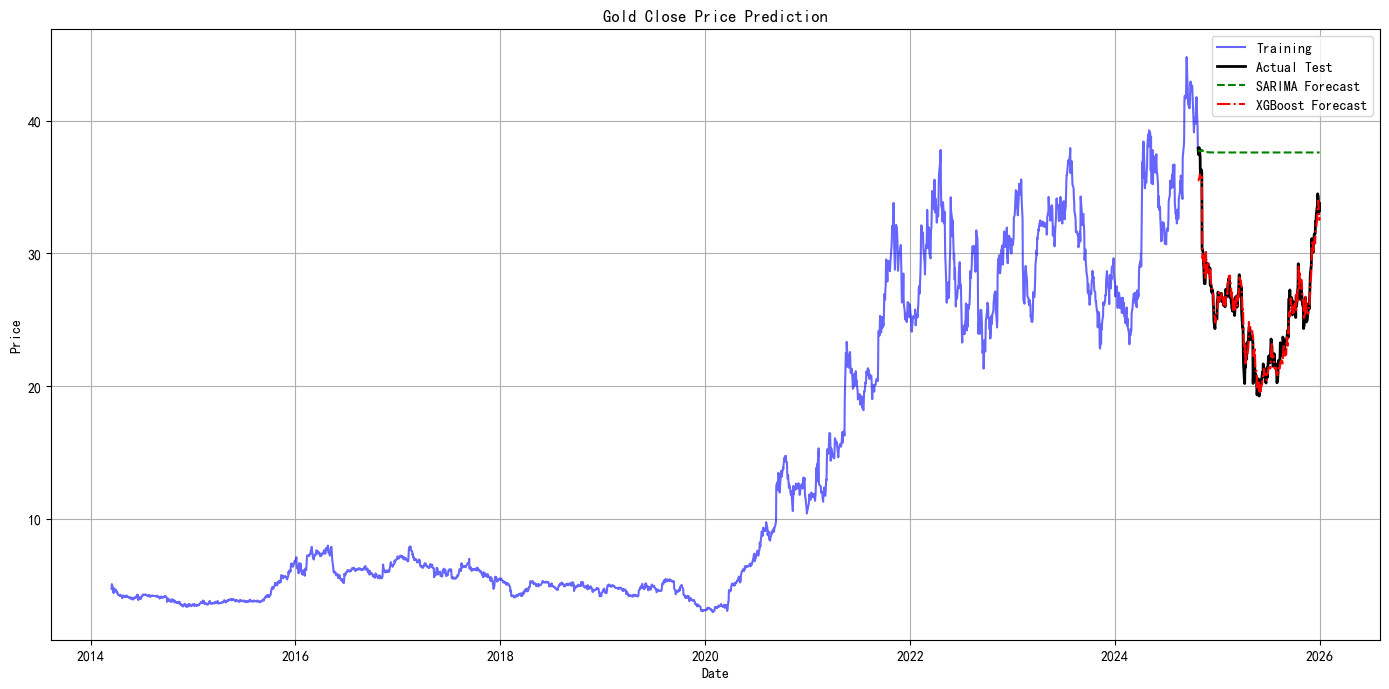

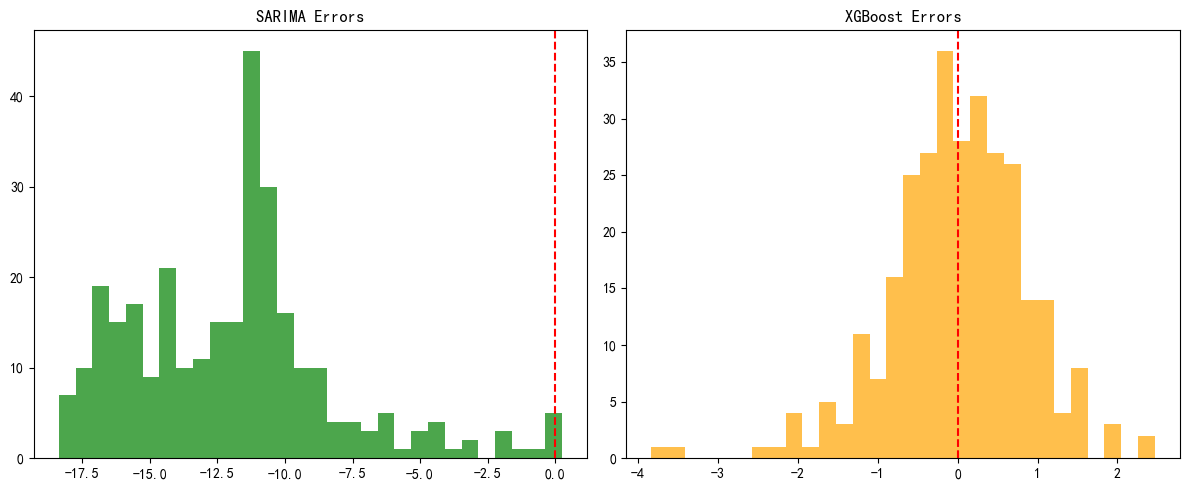

In [90]:
#预测可视化
plt.figure(figsize=(14, 7))
plt.plot(train.index, train, label='Training', color='blue', alpha=0.6)
plt.plot(test.index, test, label='Actual Test', color='black', linewidth=2)
plt.plot(test.index, sarimax_pred, label='SARIMA Forecast', color='green', linestyle='--')
plt.plot(test.index, xgb_pred, label='XGBoost Forecast', color='red', linestyle='-.')
plt.title('Gold Close Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 误差分布
errors_sarima = test - sarimax_pred
errors_xgb = test - xgb_pred
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(errors_sarima, bins=30, alpha=0.7, label='SARIMA', color='green')
plt.title('SARIMA Errors')
plt.axvline(0, color='red', linestyle='--')
plt.subplot(1,2,2)
plt.hist(errors_xgb, bins=30, alpha=0.7, label='XGBoost', color='orange')
plt.title('XGBoost Errors')
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()
